In [42]:
import shap
import numpy as np
import seaborn as sns
from torch.autograd.functional import jacobian

import data, architecture  # your modules

import matplotlib.pyplot as plt
import sys, os, time
import torch
import torch.nn as nn
import data, architecture
import optuna
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import random_split, DataLoader

mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'serif'

In [43]:
# # ====== Pick a transfer setup ======
# n_sims = 50
# n_BSQ = 22000

# # ====== Constants ======
# cosm_type = 'nwLH'
# Pk_type = 'MPk'
# params_ext = ''
# additional_extension = '_node_v2'
# additional_extension = '_fixed'
# model_type = 'dynamic'
# final_hidden_layer_size = 10
# # input_size = 79
# output_size = 6
# batch_size = 32
# seed = 42
# mode = 'test'
# param_index = 6  # For SHAP — Mnu

# # ====== Derived names and paths ======
# name = 'transfer10_network2_'+str(n_sims)+'_'+cosm_type+'_'+str(n_BSQ)+'_BSQ' + additional_extension


# study_name = str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)
# mother = '/scratch/network/vk9342/USRP2024_scratch/pytorch/'+str(Pk_type)+'_'+str(cosm_type)+'/'+str(name)+'/models/'
      

# f_params  = '../real_params/'+str(cosm_type)+'_params'+params_ext+'.txt' 
# extension = 'fhl10'
# f_Pk      = 'Pk_files/'+'all_'+cosm_type+'_'+str(n_BSQ)+'_BSQ_'+Pk_type+params_ext+'_'+str(extension)+'_fortransfer'+additional_extension+'.npy'
# input_size  = 10
# log = False
# f_Pk_norm = None

# storage    = 'sqlite:///nwLH.db'

# param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$']



# ######################################################################################
# # load the optuna study
# study = optuna.load_study(study_name=study_name, storage=storage)

# # get the scores of the study trials
# values = np.zeros(len(study.trials))
# completed = 0

# for i,t in enumerate(study.trials):
#     values[i] = t.value
#     if t.value is not None:  completed += 1

# # get the info of the best trial
# indexes = np.argsort(values)
# for indx in range(1):
#     trial = study.trials[indexes[indx]]
#     fout = 'results/Results_'+mode+'_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+params_ext+'_model'+str(indx)+'.txt'
   
#     # print("\nTrial number {}".format(trial.number))
#     # print("Value: %.5e"%trial.value)
#     for key, value in trial.params.items():
#         lr       = trial.params['lr']
#         wd       = trial.params['wd']
#         n_layers       = trial.params['n_layers']
#         p       = trial.params['dropout_l']
        
#     fmodel = mother +'model_%d.pt'%trial.number

    

#     # # generate the architecture
#     if model_type == 'dynamic_fixed_final':
#         out_fs = [trial.params[f'n_units_l{i}'] for i in range(n_layers-1)]
#         model = architecture.dynamic_model_fixed_final(trial, input_size, output_size, 
#                                                        final_hidden_layer_size, 
#                                                        n_layers, p, out_fs,
#                                                        max_neurons_layers=500)
        
#     elif model_type == 'dynamic':
#         out_fs = [trial.params[f'n_units_l{i}'] for i in range(n_layers)]
#         model = architecture.dynamic_model(trial, input_size, output_size,
#                                            n_layers, p, out_fs,
#                                            max_neurons_layers=500)   

#     else:
#         print('not a valid model')

#     # print('N BSQ: ', str(n_BSQ), 'N nwLH: ', str(n_nwLH), 'layer sizes: ', out_fs)
#     # print('N BSQ: ', str(n_BSQ), 'N nwLH: ', str(n_nwLH), 'n layers: ', n_layers)

    
#     model.to(device)  
    
#     # load best-model, if it exists
#     if os.path.exists(fmodel):  
#         print('Loading model...')
#         model.load_state_dict(torch.load(fmodel, map_location=torch.device(device)))
#     else:
#         raise Exception('model doesnt exists!!!')
    
    
#     # define loss function
#     criterion = nn.MSELoss() 
    
#     # get the data
#     test_loader = data.create_dataset(mode, seed, f_Pk, f_Pk_norm, f_params, 
#                                       batch_size, shuffle=False, workers=1, 
#                                       cosm_type =cosm_type, log=log, 
#                                       shuffle_all = True)
#     test_points = 0
#     for x,y in test_loader:  test_points += x.shape[0]
    
#     # define the arrays containing the true and predicted value of the parameters
#     params  = output_size
#     results = np.zeros((test_points, 2*params), dtype=np.float32)
    
#     # test the model
#     test_loss, points = 0.0, 0
#     model.eval()
#     X_test, Y_test = [], []
#     with torch.no_grad():
#         for x, y in test_loader:
#             X_test.append(x)
#             Y_test.append(y)
#             bs   = x.shape[0]  #batch size
#             x, y = x.to(device), y.to(device)
#             y_NN = model(x)
#             test_loss += (criterion(y_NN, y).item())*bs
#             results[points:points+bs,0*params:1*params] = y.cpu().numpy()
#             results[points:points+bs,1*params:2*params] = y_NN.cpu().numpy()
#             points    += bs
#     test_loss /= points
#     print('Test loss:', test_loss)

#     X_test = torch.cat(X_test).to(device)
#     Y_test = torch.cat(Y_test).to(device)
#     print("X_test shape:", X_test.shape)
#     print("Y_test shape:", Y_test.shape)

In [44]:
# ====== Pick a transfer setup ======
n_sims = 1400
n_sims_BSQ = 22000

# ====== Inputs ======
cosm_type = 'nwLH'
Pk_type = 'MPk'
params_ext = ''
k_max = 0.1
additional_extension = '_k_'+str(k_max)
model_type = 'dynamic'
final_hidden_layer_size = 10
log = True
if k_max == 0.5:
    input_size = 79
elif k_max == 0.3:
    input_size = 47
elif k_max == 0.1:
    input_size = 15

output_size = 6
batch_size = 32
seed = 42
mode = 'test'

# ====== names and paths ======
name = 'transfer10_network2_'+str(n_sims)+'_'+cosm_type+'_'+str(n_sims_BSQ)+'_BSQ' + additional_extension  #_fixed for fixed test/valid set

study_name = str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)
mother = '/scratch/network/vk9342/USRP2024_scratch/pytorch/'+str(Pk_type)+'_'+str(cosm_type)+'/'+str(name)+'/models/'
        
f_Pk      = 'Pk_files/'+'all_'+str(Pk_type)+'_'+str(cosm_type)+params_ext+additional_extension+'.npy'
f_params  = 'real_params/'+'all_' + str(cosm_type)+'_params'+params_ext+'.txt' 

f_Pk_norm = None

storage    = 'sqlite:///nwLH.db'

param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$']


In [35]:
## GET FINE TUNE BEST MODEL


if torch.cuda.is_available():
    print("CUDA Available")
    device = torch.device('cuda')
else:
    print('CUDA Not Available')
    device = torch.device('cpu')

add_ext = ''
BSQ_name = 'transfer10_network1_'+str(n_sims_BSQ)+'_BSQ' + additional_extension + add_ext
BSQ_study_name = 'Pk_BSQ_params_'+BSQ_name
BSQ_study = optuna.load_study(study_name=BSQ_study_name, storage=storage)
values = np.zeros(len(BSQ_study.trials))
completed = 0
for i,t in enumerate(BSQ_study.trials):
    values[i] = t.value
    if t.value is not None:  completed += 1
indexes = np.argsort(values)
for i in [0]:  #choose the best-model here, e.g. [0], or [1]
    BSQ_best_trial = BSQ_study.trials[indexes[i]]
    print("\nTrial number {}".format(BSQ_best_trial.number))
    BSQ_lr       = BSQ_best_trial.params['lr']
    BSQ_wd       = BSQ_best_trial.params['wd']
    BSQ_n_layers       = BSQ_best_trial.params['n_layers']
    print(" Params: ")
    for key, value in BSQ_best_trial.params.items():
        print("    {}: {}".format(key, value))
    BSQ_p       = BSQ_best_trial.params['dropout_l']
    if model_type == 'dynamic_fixed_final':
        BSQ_out_fs = [BSQ_best_trial.params[f'n_units_l{i}'] for i in range(BSQ_n_layers - 1)]
        BSQ_out_fhl = 10
    elif model_type == 'dynamic':
        BSQ_out_fs = [BSQ_best_trial.params[f'n_units_l{i}'] for i in range(BSQ_n_layers)]
    
########################################################################


# load the optuna study
study = optuna.load_study(study_name=study_name, storage=storage)
# get the scores of the study trials
values = np.zeros(len(study.trials))
completed = 0
for i,t in enumerate(study.trials):
    values[i] = t.value
    if t.value is not None:  completed += 1

# get the info of the best trial            
indexes = np.argsort(values)
for indx in range(1):  #choose the best-model here, e.g. [0], or [1]
    trial = study.trials[indexes[indx]]
    print("\nTrial number {}".format(trial.number))
    print("Value: %.5e"%trial.value)
    print(" Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
    lr       = trial.params['lr']
    wd       = trial.params['wd']
    # n_layers       = trial.params['n_layers']
    n_layers = BSQ_n_layers
    p = BSQ_p
    out_fs = BSQ_out_fs
    # p       = trial.params['dropout_l']
    fmodel = mother +'model_%d.pt'%trial.number

    ## generate the architecture
    # out_fs = [trial.params[f'n_units_l{i}'] for i in range(n_layers-1)]
   # generate architecture
    model = architecture.dynamic_model(trial, input_size, 
                                       output_size,
                                       BSQ_n_layers, BSQ_p, BSQ_out_fs,
                                       max_neurons_layers=500
                                      ).to(device) 

    model.to(device)  
    # load best-model, if it exists
    if os.path.exists(fmodel):  
        print('Loading model...')
        model.load_state_dict(torch.load(fmodel, map_location=torch.device(device)))
    else:
        raise Exception('model doesnt exists!!!')
    
    # define loss function
    criterion = nn.MSELoss() 

    ## GET TRAIN, VALID, TEST RESULTS
    for mode in ['test']:
        # get the data
        if mode == 'train':
                # get the data
                full_train_dataset = data.create_dataset('train', seed, f_Pk, f_Pk_norm, 
                                                   f_params, batch_size, shuffle=False, 
                                                   workers=1, cosm_type = cosm_type, log=log, 
                                                   shuffle_all=True).dataset
                train_subset, _ = torch.utils.data.random_split(full_train_dataset,
                                                                [n_sims, len(full_train_dataset) - n_sims],
                                                                generator=torch.Generator().manual_seed(seed)
                                                               )
                test_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=1)
        else:
            test_loader = data.create_dataset(mode, seed, f_Pk, f_Pk_norm, f_params, 
                                          batch_size, shuffle=False, workers=1, 
                                          cosm_type =cosm_type, log=log, 
                                          shuffle_all = True)
        
            
        
        test_points = 0
        for x,y in test_loader:  test_points += x.shape[0]
        
        # define the arrays containing the true and predicted value of the parameters
        params  = output_size
        results = np.zeros((test_points, 2*params), dtype=np.float32)
        
        # test the model
        test_loss, points = 0.0, 0
        model.eval()
        X_test, Y_test = [], []
        with torch.no_grad():
            for x, y in test_loader:
                X_test.append(x)
                Y_test.append(y)
                bs   = x.shape[0]  #batch size
                x, y = x.to(device), y.to(device)
                y_NN = model(x)
                test_loss += (criterion(y_NN, y).item())*bs
                results[points:points+bs,0*params:1*params] = y.cpu().numpy()
                results[points:points+bs,1*params:2*params] = y_NN.cpu().numpy()
                points    += bs
        test_loss /= points
        print('Test loss:', test_loss)

        X_test_ft = torch.cat(X_test).to(device)
        Y_test_ft = torch.cat(Y_test).to(device)
        print("X_test shape:", X_test_ft.shape)
        print("Y_test shape:", Y_test_ft.shape)

CUDA Available

Trial number 68
 Params: 
    lr: 0.0004802356593484601
    wd: 1.6904103246647734e-07
    n_layers: 2
    dropout_l: 0.21283863968789135
    n_units_l0: 480
    n_units_l1: 333

Trial number 61
Value: 3.18876e-02
 Params: 
    lr: 0.0001595903754007476
    wd: 0.06927782761725756
Loading model...
Test loss: 0.03450637355446815
X_test shape: torch.Size([300, 15])
Y_test shape: torch.Size([300, 6])


In [36]:
def model_forward(x_np):
    x_tensor = torch.tensor(x_np, dtype=torch.float32).to(device)
    with torch.no_grad():
        return model(x_tensor).cpu().numpy()


# X_shap = X_test[:100].detach().cpu().numpy()
X_shap_ft = X_test_ft.detach().cpu().numpy()


explainer_ft = shap.Explainer(model_forward, X_shap_ft)
shap_values_ft = explainer_ft(X_shap_ft)  # shape: [100, 79, 6]
print(shap_values_ft.shape)

idx_omega_m = 0  
idx_sigma8 = 4
idx_mnu = 5

shap_omega_m_ft = np.mean(shap_values_ft.values[:, :, idx_omega_m], axis=0)
shap_sigma8_ft  = np.mean(shap_values_ft.values[:, :, idx_sigma8], axis=0)
shap_mnu_ft     = np.mean(shap_values_ft.values[:, :, idx_mnu], axis=0)


PermutationExplainer explainer: 301it [02:02,  2.12it/s]                         

(300, 15, 6)


In [39]:
## GET PRETRAIN BEST MODEL
# ====== Pick a transfer setup ======
n_sims_BSQ = 22000

# ====== Inputs ======
cosm_type = 'nwLH'
Pk_type = 'Pk'
params_ext = ''
k_max = 0.3
additional_extension = '_k_'+str(k_max)
model_type = 'dynamic'
final_hidden_layer_size = 10
log = True

if k_max == 0.5:
    input_size = 79
elif k_max == 0.3:
    input_size = 47
elif k_max == 0.1:
    input_size = 15

output_size = 6

add_ext = ''
params_ext = ''

BSQ_name = 'transfer10_network1_'+str(n_sims_BSQ)+'_BSQ' + additional_extension + add_ext
BSQ_study_name = 'Pk_BSQ_params_'+BSQ_name

Pk_type = 'Pk'
cosm_type = 'BSQ'
BSQ_mother = '/scratch/network/vk9342/USRP2024_scratch/pytorch/'+str(Pk_type)+'_'+str(cosm_type)+'/'+str(BSQ_name)+'/models/'
 

f_Pk      = 'Pk_files/'+'all_'+str(Pk_type)+'_'+str(cosm_type)+params_ext+additional_extension+'.npy'
f_params  = 'real_params/' + 'all_'+str(cosm_type)+'_params'+params_ext+'.txt' 
f_Pk_norm = None

batch_size = 32
seed = 42
mode = 'test'
storage    = 'sqlite:///nwLH.db'
param_names = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$']


if torch.cuda.is_available():
    print("CUDA Available")
    device = torch.device('cuda')
else:
    print('CUDA Not Available')
    device = torch.device('cpu')


BSQ_study = optuna.load_study(study_name=BSQ_study_name, storage=storage)
values = np.zeros(len(BSQ_study.trials))
completed = 0
for i,t in enumerate(BSQ_study.trials):
    values[i] = t.value
    if t.value is not None:  completed += 1

indexes = np.argsort(values)
for i in [0]:  #choose the best-model here, e.g. [0], or [1]
    BSQ_best_trial = BSQ_study.trials[indexes[i]]
    print("\nTrial number {}".format(BSQ_best_trial.number))
    print("Value: %.5e"%BSQ_best_trial.value)
    print(" Params: ")
    for key, value in BSQ_best_trial.params.items():
        print("    {}: {}".format(key, value))

    BSQ_lr       = BSQ_best_trial.params['lr']
    BSQ_wd       = BSQ_best_trial.params['wd']
    BSQ_n_layers       = BSQ_best_trial.params['n_layers']
    BSQ_p       = BSQ_best_trial.params['dropout_l']
    fmodel = BSQ_mother +'model_%d.pt'%BSQ_best_trial.number
    
    if model_type == 'dynamic_fixed_final':
        BSQ_out_fs = [BSQ_best_trial.params[f'n_units_l{i}'] for i in range(BSQ_n_layers - 1)]
        BSQ_out_fhl = 10
    elif model_type == 'dynamic':
        BSQ_out_fs = [BSQ_best_trial.params[f'n_units_l{i}'] for i in range(BSQ_n_layers)]


    model = architecture.dynamic_model(BSQ_best_trial, input_size, 
                                       output_size,
                                       BSQ_n_layers, BSQ_p, BSQ_out_fs,
                                       max_neurons_layers=500
                                      ).to(device) 

    model.to(device)  
    # load best-model, if it exists
    if os.path.exists(fmodel):  
        print('Loading model...')
        model.load_state_dict(torch.load(fmodel, map_location=torch.device(device)))
    else:
        raise Exception('model doesnt exists!!!')
    
    # define loss function
    criterion = nn.MSELoss() 

    ## GET TRAIN, VALID, TEST RESULTS
    for mode in ['test']:
        # get the data
        if mode == 'train':
                # get the data
                full_train_dataset = data.create_dataset('train', seed, f_Pk, f_Pk_norm, 
                                                   f_params, batch_size, shuffle=False, 
                                                   workers=1, cosm_type = cosm_type, log=log, 
                                                   shuffle_all=True).dataset
                train_subset, _ = torch.utils.data.random_split(full_train_dataset,
                                                                [n_sims, len(full_train_dataset) - n_sims],
                                                                generator=torch.Generator().manual_seed(seed)
                                                               )
                test_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=1)
        else:
            test_loader = data.create_dataset(mode, seed, f_Pk, f_Pk_norm, f_params, 
                                          batch_size, shuffle=False, workers=1, 
                                          cosm_type =cosm_type, log=log, 
                                          shuffle_all = True)
        
            
        
        test_points = 0
        for x,y in test_loader:  test_points += x.shape[0]
        
        # define the arrays containing the true and predicted value of the parameters
        params  = output_size-1
        results = np.zeros((test_points, 2*params), dtype=np.float32)
        
        # test the model
        test_loss, points = 0.0, 0
        model.eval()
        X_test, Y_test = [], []
        with torch.no_grad():
            for x, y in test_loader:
                X_test.append(x)
                Y_test.append(y)
                bs   = x.shape[0]  #batch size
                x, y = x.to(device), y.to(device)
                y_NN = model(x)
                test_loss += (criterion(y_NN[:, :5], y).item())*bs
                results[points:points+bs,0*params:1*params] = y.cpu().numpy()
                results[points:points+bs,1*params:2*params] = y_NN[:, :5].cpu().numpy()
                points    += bs
        test_loss /= points
        print('Test loss:', test_loss)

        X_test_pretrain = torch.cat(X_test).to(device)
        Y_test_pretrain = torch.cat(Y_test).to(device)
        print("X_test shape:", X_test_pretrain.shape)
        print("Y_test shape:", Y_test_pretrain.shape)

CUDA Available

Trial number 45
Value: 1.65780e-02
 Params: 
    lr: 0.00024354085615752255
    wd: 1.5453491732127728e-07
    n_layers: 3
    dropout_l: 0.32754409586382405
    n_units_l0: 466
    n_units_l1: 374
    n_units_l2: 480
Loading model...
Test loss: 0.01630851355691751
X_test shape: torch.Size([4800, 47])
Y_test shape: torch.Size([4800, 5])


## SHAP

In [40]:
def model_forward(x_np):
    x_tensor = torch.tensor(x_np, dtype=torch.float32).to(device)
    with torch.no_grad():
        return model(x_tensor).cpu().numpy()


# X_shap = X_test[:100].detach().cpu().numpy()
X_shap_pretrain = X_test_pretrain.detach().cpu().numpy()


explainer_pretrain = shap.Explainer(model_forward, X_shap_pretrain)
shap_values_pretrain = explainer_pretrain(X_shap_pretrain)  # shape: [100, 79, 6]
print(shap_values_pretrain.shape)

idx_omega_m = 0  
idx_sigma8 = 4
idx_mnu = 5

shap_omega_m_pretrain = np.mean(shap_values_pretrain.values[:, :, idx_omega_m], axis=0)
shap_sigma8_pretrain  = np.mean(shap_values_pretrain.values[:, :, idx_sigma8], axis=0)
# shap_mnu_ft     = np.mean(shap_values.values[:, :, idx_mnu], axis=0)





PermutationExplainer explainer: 4801it [25:04,  3.16it/s]                          

(4800, 47, 6)


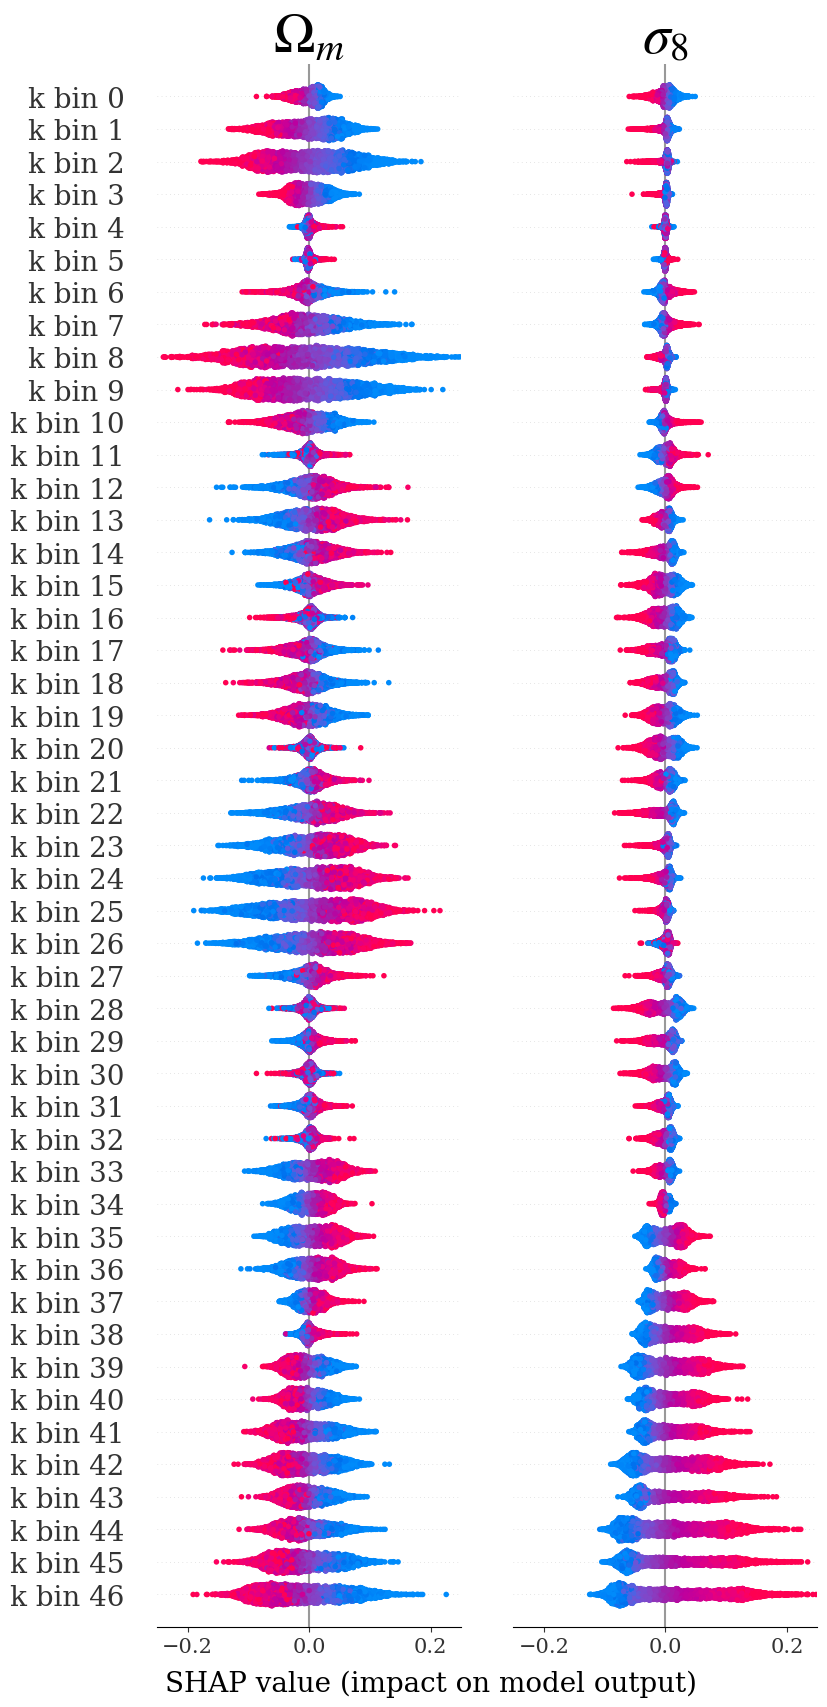

In [41]:
# Plot each beeswarm
idx_omega_m = 0  
idx_sigma8 = 4
idx_mnu = 5

output_size = 47

output_params = [r'$\Omega_m$', r'$\sigma_8$', r'$M_{\nu}$']

network_type = 'pretrain'

if network_type == 'pretrain':
    output_indices = [idx_omega_m, idx_sigma8]
    shap_values = shap_values_pretrain
    fig_file_name = 'SHAP_plots_pretrain_'+str(k_max)

elif network_type == 'finetune':
    output_indices = [idx_omega_m, idx_sigma8, idx_mnu]
    shap_values = shap_values_ft
    fig_file_name = 'SHAP_plots_finetune_'+str(k_max)
else:
    print('error')


n = len(output_indices)  # 2 for pretrain, 3 for finetune
per_panel_w = 12.0
ratio = 1/6  # height/width
fig_w = per_panel_w * n
fig_h = ratio * fig_w

fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h), sharey=True, constrained_layout=False)
fig.subplots_adjust(wspace=0.35) 
for i, idx in enumerate(output_indices):
    plt.sca(axes[i])
    pos = axes[i].get_position()
    axes[i].set_position([
        pos.x0 - 0.01,  # shift slightly left
        pos.y0,
        pos.width + 0.05,  # stretch wider
        pos.height
    ])
    shap.plots.beeswarm(shap_values[:, :, idx], 
                        max_display = output_size, 
                        order=range(shap_values.values.shape[1]),
                        show=False,
                        color_bar=False if (i < len(output_indices)-1 or network_type == 'pretrain') else True,
                       )
    # rasterize heavy artists (scatter, etc.)
    for coll in axes[i].collections:
        try:
            coll.set_rasterized(True)
        except Exception:
            pass

    
    if i != 1:
        axes[i].set_xlabel("")
    
    if i == 0 and network_type == 'pretrain':
        axes[i].set_xlabel("SHAP value (impact on model output)", labelpad=10, size = 20)
        axes[i].xaxis.get_label().set_x(0.90)
        # axes[i].xaxis.set_label_coords(0.6, -0.1) 
    if i == 1 and network_type == 'pretrain':
        axes[i].set_xlabel("")
    
    if i == 1 and network_type == 'finetune':
        axes[i].set_xlabel("SHAP value (impact on model output)", labelpad=10, size = 20)


    axes[i].set_title(f"{output_params[i]}", size = 40)

    if i == len(output_indices)-1 and network_type == 'finetune':
        fig = plt.gcf()
        cbar = fig.axes[-1]  # last Axes in fig is usually the colorbar
        cbar.set_ylabel("MP(k) value", size = 30)
        cbar.tick_params(labelsize=20)


    axes[i].tick_params(axis='x', which='both', labelsize=15)

    # FORCE X AXES TO BE FROM -0.25 TO 0.25
    xlim = (-0.25, 0.25)
    xticks = [-0.2, 0.0, 0.2]
    for ax in axes:
        ax.autoscale(enable=False, axis='x', tight=False)
        ax.set_autoscalex_on(False)
        for art in list(ax.lines) + list(ax.collections):
            try:
                art.sticky_edges.x[:] = []
            except Exception:
                pass
        ax.set_xmargin(0)
        ax.set_xlim(*xlim)
        ax.set_xticks(xticks)





yticks = np.arange(output_size)  # 0 to 79 if you're displaying 80 features
yticklabels = [f"k bin {n}" for n in yticks[::-1]]
axes[0].set_yticks(yticks)
axes[0].set_yticklabels(yticklabels, size = 20)


# plt.tight_layout()
plt.savefig(fig_file_name+'.pdf', format="pdf", bbox_inches="tight")
plt.show()

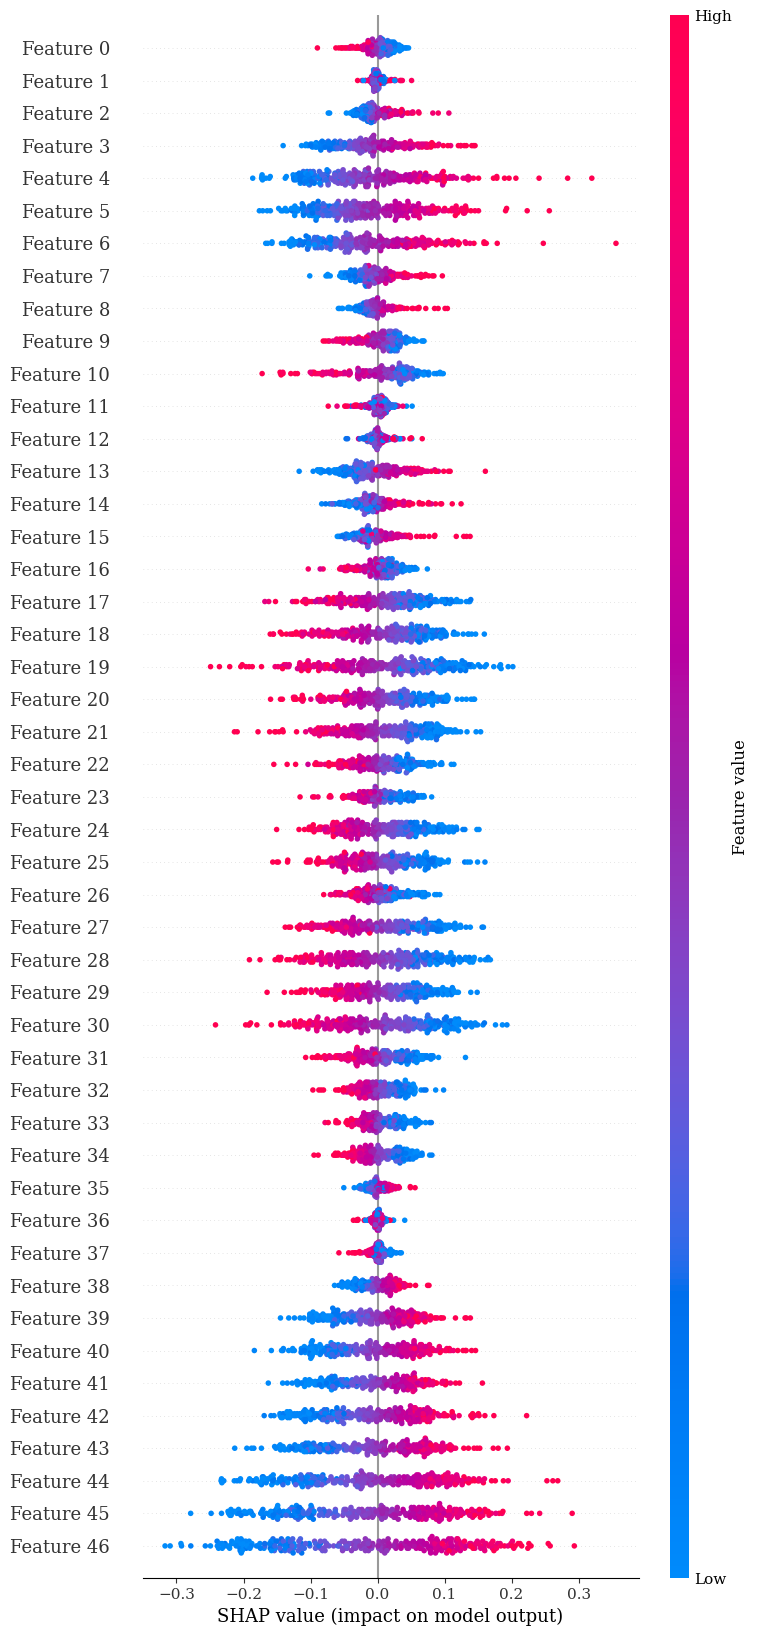

In [6]:


shap.plots.beeswarm(shap_values_ft[:, :, idx_mnu], max_display = 80, order=range(shap_values_ft.values.shape[1]))



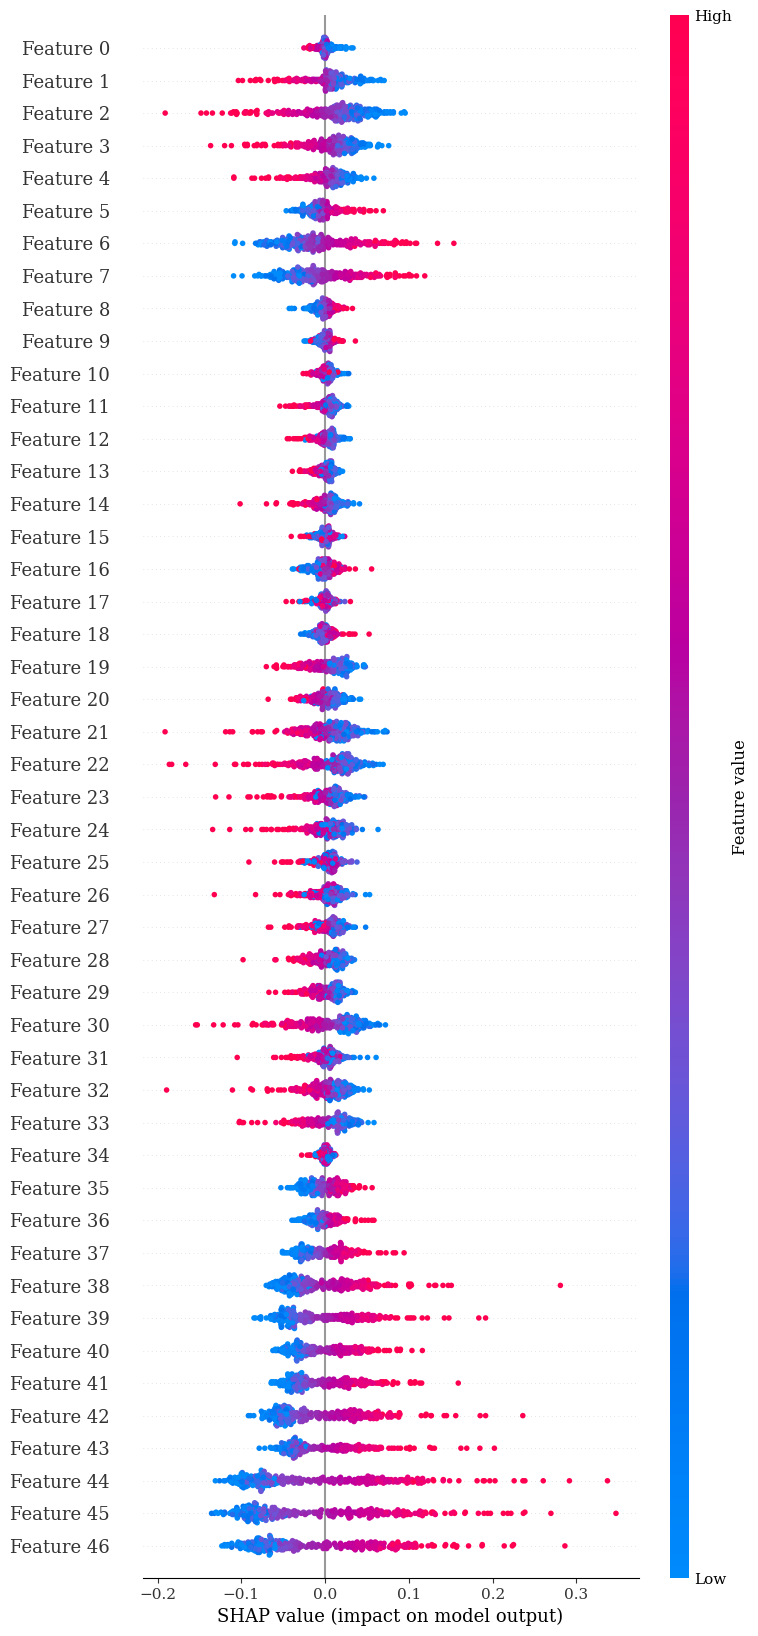

In [7]:
shap.plots.beeswarm(shap_values_ft[:, :, idx_sigma8], max_display = 80, order=range(shap_values_ft.values.shape[1]))


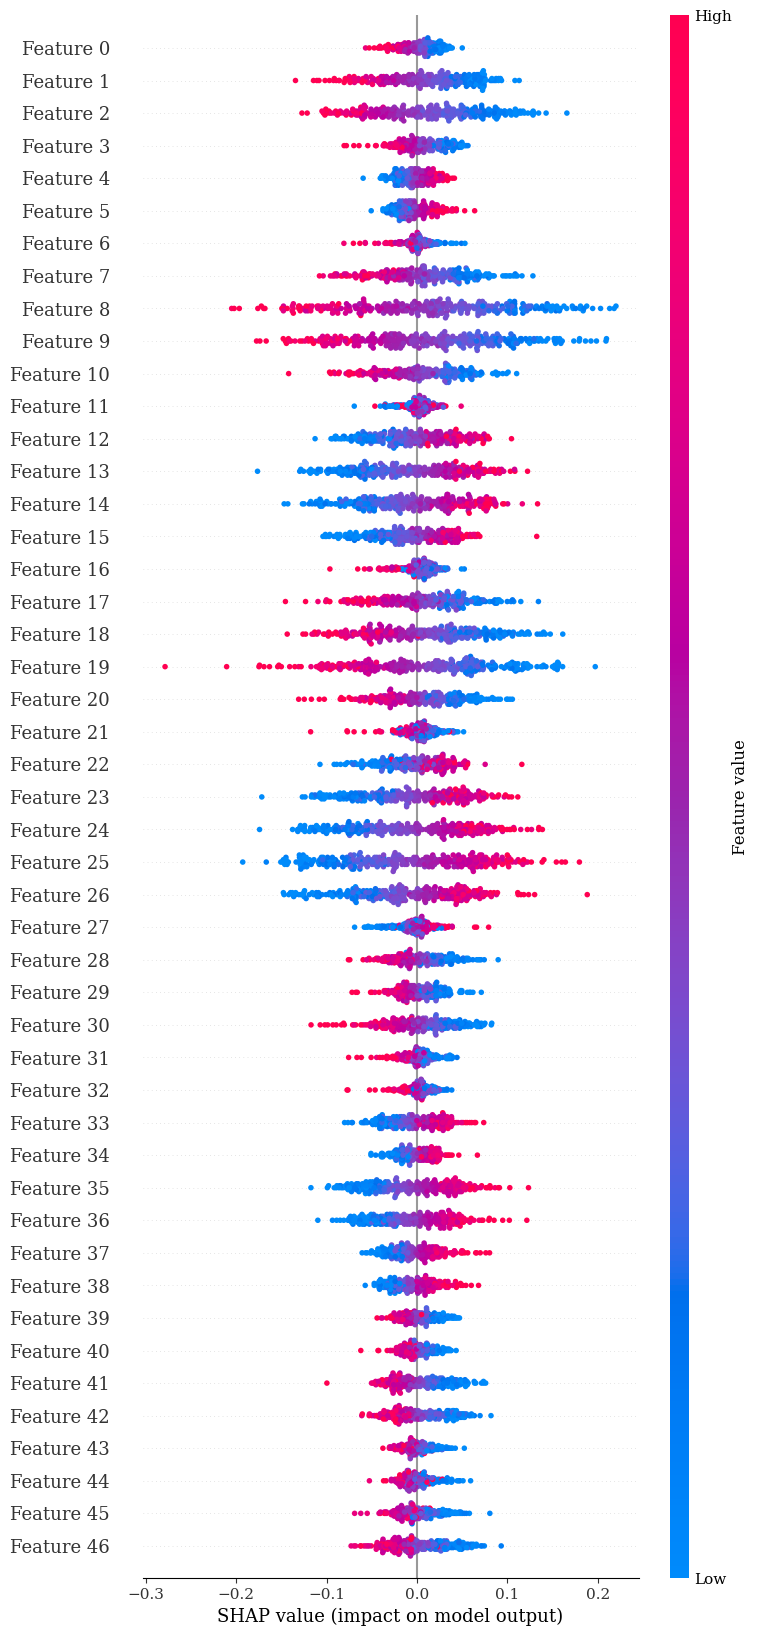

In [8]:
shap.plots.beeswarm(shap_values_ft[:, :, idx_omega_m], max_display = 80, order=range(shap_values_ft.values.shape[1]))
